**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Elda Estefanía Lara Cruz
*   MATRÍCULA: A01747420


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [2]:
# Importa las librerías necesarias
import warnings
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





In [10]:
# Carga el archivo en un dataframe
weather_df = pd.read_csv("/content/cleaned_weather.csv")

# Dimensionalidad (filas, columnas) e identificadores de columnas
print("Dimensionalidad (filas, columnas):", weather_df.shape)
print("Columnas:", list(weather_df.columns))

# Renombra las columnas
nuevos_nombres = ["medicion", "presion_atmosferica", "temperatura_celsius", "temperatura_kelvin",
                  "humedad_relativa", "presion_vapor", "humedad_especifica", "concentracion_vapor",
                  "densidad_aire", "velocidad_viento", "direccion_viento", "precipitacion_total",
                  "duracion_lluvia"]
weather_df = weather_df.rename(columns=dict(zip(weather_df.columns, nuevos_nombres)))
weather_df.columns

# Primeros y últimos 5 registros
display(weather_df.head())
display(weather_df.tail())

# ¿Hay valores faltantes?
print(weather_df.isna().sum())
print("¿Hay faltantes?:", weather_df.isna().any().any())


Dimensionalidad (filas, columnas): (52696, 13)
Columnas: ['timestamp', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv', 'wd', 'rain', 'raining']


,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,01/01/20 0:40,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,01/01/20 0:50,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0


,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,31/12/20 23:20,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0
52692,31/12/20 23:30,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0
52693,31/12/20 23:40,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0
52694,31/12/20 23:50,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0
52695,01/01/21 0:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0


medicion               0
presion_atmosferica    0
temperatura_celsius    0
temperatura_kelvin     0
humedad_relativa       0
presion_vapor          0
humedad_especifica     0
concentracion_vapor    0
densidad_aire          0
velocidad_viento       0
direccion_viento       0
precipitacion_total    0
duracion_lluvia        0
dtype: int64
¿Hay faltantes?: False


2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [11]:

# Tipo de datos de cada columna
weather_df.dtypes

# Convierte medicion a datetime con el formato indicado
weather_df["medicion"] = pd.to_datetime(weather_df["medicion"], format="%d/%m/%y %H:%M")
weather_df["medicion"].dtype

# Separa medicion en fecha y hora
weather_df["fecha"] = weather_df["medicion"].dt.date
weather_df["hora"] = weather_df["medicion"].dt.time
weather_df[["medicion", "fecha", "hora"]].head()


,medicion,fecha,hora
0,2020-01-01 00:10:00,2020-01-01,00:10:00
1,2020-01-01 00:20:00,2020-01-01,00:20:00
2,2020-01-01 00:30:00,2020-01-01,00:30:00
3,2020-01-01 00:40:00,2020-01-01,00:40:00
4,2020-01-01 00:50:00,2020-01-01,00:50:00


3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [12]:
# Cantidad de valores únicos por columna
weather_df.nunique()

# Identifica la fecha duplicada (keep=False muestra las dos filas repetidas)
fechas_duplicadas = weather_df[weather_df["medicion"].duplicated(keep=False)]
display(fechas_duplicadas)

# Comprueba si las filas son idénticas en todas las columnas y elimina una
print("¿Registros completamente idénticos?:", weather_df.duplicated().sum() == 1)
weather_df = weather_df.drop_duplicates().reset_index(drop=True)
weather_df.shape


,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
19043,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00
19044,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00


¿Registros completamente idénticos?: True


(52695, 15)

4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [13]:
# Valores únicos por columna después de eliminar el duplicado
weather_df.nunique()

# ¿Por qué 144 horas diferentes? Se listan las horas únicas
horas = weather_df["hora"].sort_values().unique()
print(len(horas), horas[:4], "...", horas[-2:])

# Fechas con mediciones faltantes: cada día debería tener 144 mediciones
conteo_por_fecha = weather_df.groupby("fecha").size()
fechas_incompletas = conteo_por_fecha[conteo_por_fecha != 144]
print("Fechas con != 144 mediciones:")
print(fechas_incompletas)

# Marcas de tiempo esperadas (cada 10 min) vs. las que realmente existen
esperadas = pd.date_range("2020-01-01 00:10", "2021-01-01 00:00", freq="10min")
faltantes = esperadas.difference(weather_df["medicion"])
print("\nTotal de mediciones omitidas:", len(faltantes))
print(faltantes)

# Elimina los registros que no son de 2020 y la columna medicion
weather_df = weather_df[weather_df["medicion"].dt.year == 2020].drop(columns="medicion")
print(weather_df.shape)
weather_df.head(2)


144 [datetime.time(0, 0) datetime.time(0, 10) datetime.time(0, 20)
 datetime.time(0, 30)] ... [datetime.time(23, 40) datetime.time(23, 50)]
Fechas con != 144 mediciones:
fecha
2020-01-01    143
2020-05-29    135
2021-01-01      1
dtype: int64

Total de mediciones omitidas: 9
DatetimeIndex(['2020-05-29 09:40:00', '2020-05-29 09:50:00',
               '2020-05-29 10:00:00', '2020-05-29 10:10:00',
               '2020-05-29 10:20:00', '2020-05-29 10:30:00',
               '2020-05-29 10:40:00', '2020-05-29 10:50:00',
               '2020-05-29 11:00:00'],
              dtype='datetime64[ns]', freq='10min')
(52694, 14)


,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
0,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0,2020-01-01,00:10:00
1,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0,2020-01-01,00:20:00


5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [15]:
# Dataframe con el mayor valor de cada indicador por fecha (se excluye hora, que no es numérica)
columnas_numericas = weather_df.columns.drop(["fecha", "hora"])
indicadores_diarios = weather_df.groupby("fecha")[list(columnas_numericas)].max()
indicadores_diarios.head()

# Máxima precipitación y su fecha
dia_max = indicadores_diarios["precipitacion_total"].idxmax()
print("Máxima precipitación:", indicadores_diarios["precipitacion_total"].max(), "mm el", dia_max)

# Tres días con las velocidades de viento más altas
indicadores_diarios["velocidad_viento"].nlargest(3)
top3_viento = indicadores_diarios[["velocidad_viento"]].nlargest(3, "velocidad_viento")
display(top3_viento)

# Días que rebasaron el 90% de humedad relativa y los 30 °C
humedad_90 = (indicadores_diarios["humedad_relativa"] > 90).sum()
temp_30 = (indicadores_diarios["temperatura_celsius"] > 30).sum()
ambos = ((indicadores_diarios["humedad_relativa"] > 90) & (indicadores_diarios["temperatura_celsius"] > 30)).sum()
print("Días con humedad > 90%:", humedad_90)
print("Días con temperatura > 30 °C:", temp_30)
print("Días con ambas condiciones:", ambos)


Máxima precipitación: 11.2 mm el 2020-06-16


,velocidad_viento
fecha,
2020-02-10,13.77
2020-02-16,13.00
2020-02-09,12.52


Días con humedad > 90%: 221
Días con temperatura > 30 °C: 9
Días con ambas condiciones: 5


6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [16]:
# Estadísticas descriptivas de indicadores_diarios
descripcion = indicadores_diarios.describe()
display(descripcion)

# Valores solicitados extraídos de describe()
print("Desv. estándar concentracion_vapor:", descripcion.loc["std", "concentracion_vapor"])
print("Mediana presion_atmosferica:", descripcion.loc["50%", "presion_atmosferica"])
print("Q3 duracion_lluvia:", descripcion.loc["75%", "duracion_lluvia"])


,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,992.977842,15.343770,289.431667,90.886530,11.409454,7.214016,11.539180,1232.622814,5.245164,317.673689,0.314208,240.382514
std,8.543447,7.850339,7.942175,9.201588,4.507555,2.872647,4.573267,32.702446,2.097012,50.611324,0.979721,273.840002
min,959.900000,-0.120000,273.460000,55.440000,3.320000,2.050000,3.290000,1167.050000,1.570000,69.570000,0.000000,0.000000
25%,988.015000,8.840000,282.732500,85.400000,7.647500,4.832500,7.742500,1207.590000,3.662500,279.075000,0.000000,0.000000
50%,993.300000,15.060000,289.160000,93.250000,10.715000,6.705000,10.735000,1231.455000,4.880000,346.650000,0.000000,0.000000
75%,998.432500,21.695000,295.957500,99.900000,14.462500,9.180000,14.685000,1256.057500,6.495000,357.300000,0.200000,600.000000
max,1020.070000,34.800000,309.130000,100.000000,24.160000,15.400000,24.530000,1318.520000,13.770000,360.000000,11.200000,600.000000


Desv. estándar concentracion_vapor: 4.573267035838971
Mediana presion_atmosferica: 993.3
Q3 duracion_lluvia: 600.0


Desviación estándar de la concentración de vapor (≈ 4.57 mmol/mol): indica cuánto se alejan, en promedio, los máximos diarios respecto a su media (≈ 11.54 mmol/mol). Es una dispersión alta (cerca del 40 % de la media), reflejo de la diferencia entre el aire seco y frío del invierno y el húmedo y cálido del verano.

Mediana de la presión atmosférica (993.3 mbar): la mitad de los días tuvo un máximo de presión por debajo de este valor y la otra mitad por encima. Al ser casi igual a la media (≈ 992.98 mbar), la distribución es aproximadamente simétrica y sin valores extremos que la distorsionen.

Tercer cuartil de la duración de la lluvia (600 s): el 75 % de los días tuvo una duración máxima de lluvia de 600 s o menos. Como 600 s es también el máximo posible en un intervalo de 10 minutos, al menos un 25 % de los días tuvo un intervalo con lluvia continua durante todo el periodo. Además, el primer cuartil y la mediana son 0, así que más de la mitad de los días no tuvo lluvia.


7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

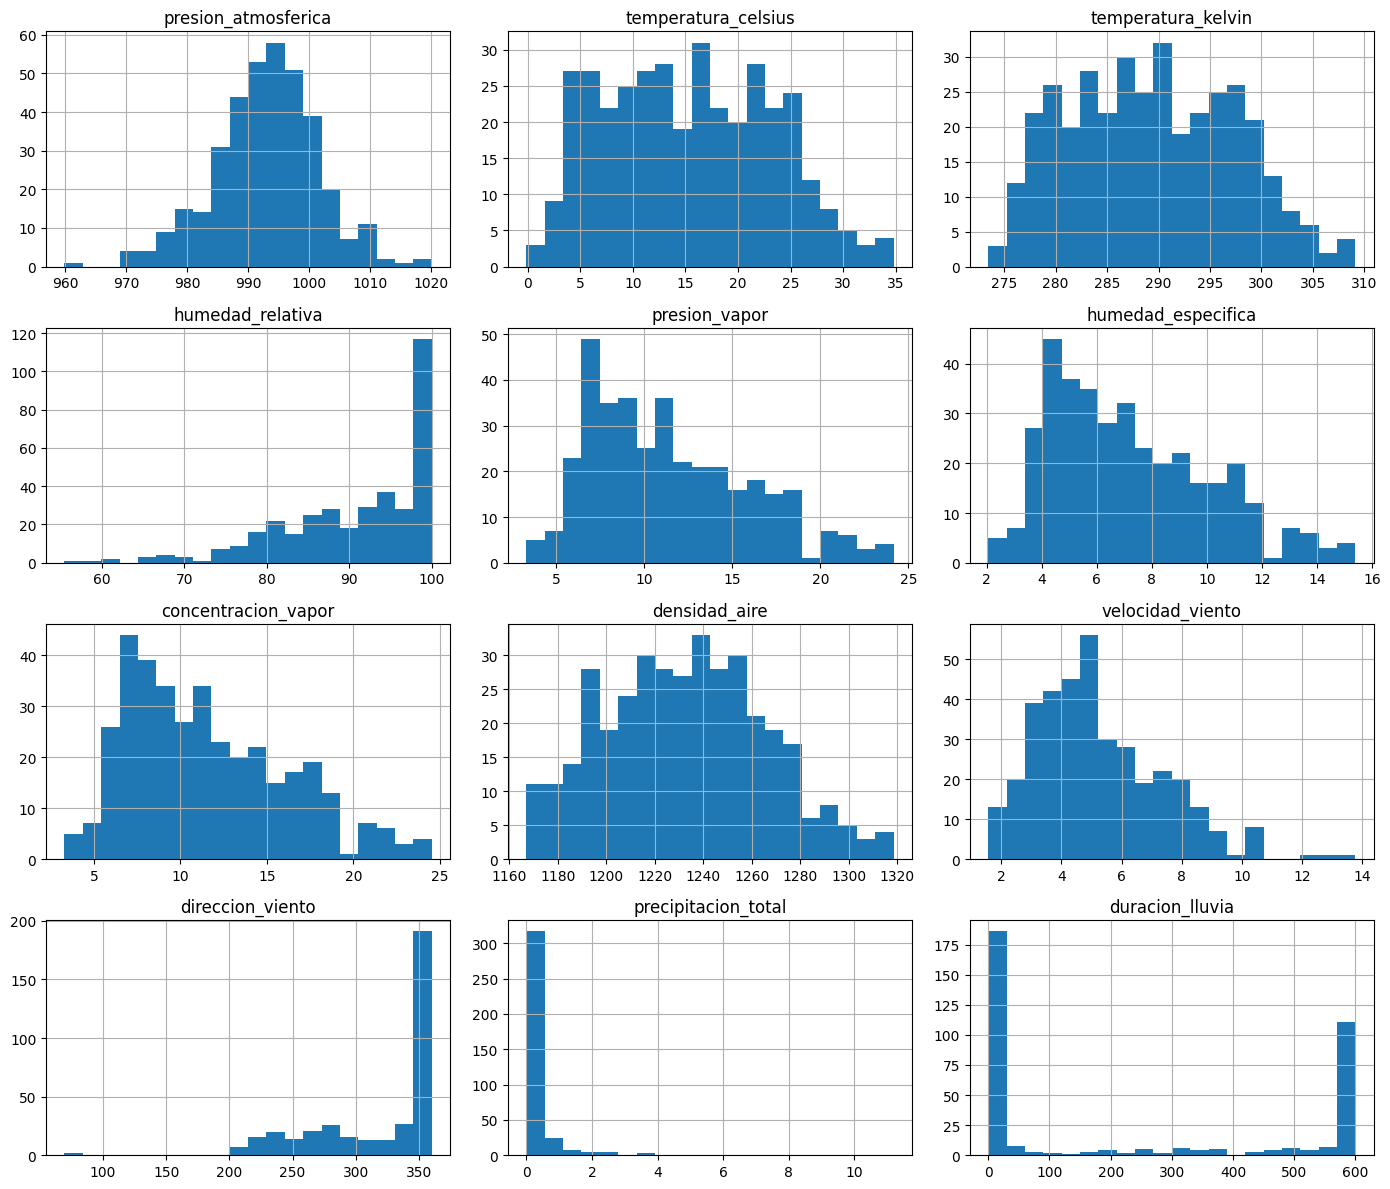

In [17]:
# Histograma para cada columna de indicadores_diarios
indicadores_diarios.hist(bins=20, figsize=(14, 12), layout=(4, 3))
plt.tight_layout()
plt.show()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [18]:
# Crea la columna mes a partir de la fecha que está en el índice
indicadores_diarios["mes"] = pd.to_datetime(indicadores_diarios.index).month
indicadores_diarios[["mes"]].head(3)

# Promedios mensuales con groupby(), conservando solo las 3 columnas pedidas
columnas_mensuales = ["humedad_relativa", "temperatura_celsius", "velocidad_viento"]
indicadores_mensuales = indicadores_diarios.groupby("mes")[columnas_mensuales].mean()
display(indicadores_mensuales)


,humedad_relativa,temperatura_celsius,velocidad_viento
mes,,,
1,89.776129,6.821290,5.031935
2,85.719655,8.962414,7.489655
3,85.372903,9.683871,6.421290
4,80.938667,16.879667,4.997000
5,87.464839,17.135484,4.865806
6,94.256000,22.212000,5.296667
7,85.959355,24.336129,4.830323
8,92.002581,26.097742,5.040323
9,97.570000,21.571667,4.153333


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [21]:
# Mismo dataframe mensual, con pivot_table()
indicadores_mensuales_pivot = indicadores_diarios.pivot_table(
    index="mes", values=columnas_mensuales, aggfunc="mean")[columnas_mensuales]
display(indicadores_mensuales_pivot)

# Añade indice_calor con la fórmula de Thom
indicadores_mensuales_pivot["indice_calor"] = (
    indicadores_mensuales_pivot["temperatura_celsius"]
    + 0.33 * indicadores_mensuales_pivot["humedad_relativa"]
    - 0.7 * indicadores_mensuales_pivot["velocidad_viento"] - 4)
display(indicadores_mensuales_pivot)


,humedad_relativa,temperatura_celsius,velocidad_viento
mes,,,
1,89.776129,6.821290,5.031935
2,85.719655,8.962414,7.489655
3,85.372903,9.683871,6.421290
4,80.938667,16.879667,4.997000
5,87.464839,17.135484,4.865806
6,94.256000,22.212000,5.296667
7,85.959355,24.336129,4.830323
8,92.002581,26.097742,5.040323
9,97.570000,21.571667,4.153333


,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
mes,,,,
1,89.776129,6.821290,5.031935,28.925058
2,85.719655,8.962414,7.489655,28.007141
3,85.372903,9.683871,6.421290,29.362026
4,80.938667,16.879667,4.997000,36.091527
5,87.464839,17.135484,4.865806,38.592816
6,94.256000,22.212000,5.296667,45.608813
7,85.959355,24.336129,4.830323,45.321490
8,92.002581,26.097742,5.040323,48.930368
9,97.570000,21.571667,4.153333,46.862433


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [22]:
# Formato largo con melt(): mes pasa de índice a columna fija (id_vars)
largo_melt = indicadores_mensuales_pivot.reset_index().melt(
    id_vars="mes", var_name="indicador", value_name="valor")
display(largo_melt.head(14))

# Formato largo con stack(): apila el nivel inferior de las columnas hacia el índice
largo_stack = indicadores_mensuales_pivot.stack()
print(type(largo_stack))
display(largo_stack.head(14))


,mes,indicador,valor
0,1,humedad_relativa,89.776129
1,2,humedad_relativa,85.719655
2,3,humedad_relativa,85.372903
3,4,humedad_relativa,80.938667
4,5,humedad_relativa,87.464839
5,6,humedad_relativa,94.256000
6,7,humedad_relativa,85.959355
7,8,humedad_relativa,92.002581
8,9,humedad_relativa,97.570000
9,10,humedad_relativa,96.950645


<class 'pandas.core.series.Series'>


mes                     
1    humedad_relativa       89.776129
     temperatura_celsius     6.821290
     velocidad_viento        5.031935
     indice_calor           28.925058
2    humedad_relativa       85.719655
     temperatura_celsius     8.962414
     velocidad_viento        7.489655
     indice_calor           28.007141
3    humedad_relativa       85.372903
     temperatura_celsius     9.683871
     velocidad_viento        6.421290
     indice_calor           29.362026
4    humedad_relativa       80.938667
     temperatura_celsius    16.879667
dtype: float64

Diferencias entre melt() y stack():
Control: melt() permite indicar con id_vars, value_vars, var_name y value_name qué columnas quedan fijas, cuáles se quitan (derriten) y cómo se llaman las nuevas columnas. stack() no tiene esos parámetros: siempre apila el nivel inferior de las columnas hacia el índice.

Dónde queda mes: en melt() se necesita convertir antes el índice en columna (reset_index()) y mes queda como columna. En stack() mes se mantiene en el índice y el nombre del indicador pasa a ser un segundo nivel del índice.

Resultado: melt() devuelve un DataFrame con índice numérico y columnas mes, indicador, valor. stack() devuelve una Series con MultiIndex (mes, indicador), que se puede llevar a DataFrame con reset_index().
Orden de las filas: melt() recorre columna por columna (primero los 12 meses de humedad, luego los de temperatura, etc.), mientras que stack() recorre fila por fila (para cada mes, todos sus indicadores).


---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   OpenAI. (2026). *ChatGPT (basado en GPT-4)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://chat.openai.com/

---